# Network Intrusion Detection with Predictive Modeling


## Setup: Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, IsolationForest
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
print("All libraries loaded successfully!")

All libraries loaded successfully!


---
## Part A: Data Preparation

### Data Loading and Cleaning


In [2]:
# NSL-KDD column names
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

# Load training and test sets (no header row in NSL-KDD)
df_train = pd.read_csv("KDDTrain+.csv", header=None, names=col_names)
df_test  = pd.read_csv("KDDTest+.csv",  header=None, names=col_names)

# Drop the difficulty column — not needed for modelling
df_train = df_train.drop(columns=["difficulty"])
df_test  = df_test.drop(columns=["difficulty"])

# Check for missing values
print("Missing values in training set:")
print(df_train.isnull().sum().sum(), "total missing values")

# Check for duplicates
print(f"\nDuplicate rows in training set: {df_train.duplicated().sum()}")
df_train = df_train.drop_duplicates()

# Shape and preview
print(f"\nTraining set shape: {df_train.shape}")
print(f"Test set shape    : {df_test.shape}")
df_train.head()

Missing values in training set:
0 total missing values

Duplicate rows in training set: 0

Training set shape: (125973, 42)
Test set shape    : (22543, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


The NSL-KDD dataset has no header row so we assign column names manually. We drop the `difficulty` column as it is a meta-attribute not useful for intrusion detection. There are no missing values in NSL-KDD, making it one of the cleaner benchmark datasets. We also remove duplicate rows to avoid bias during training.

### Exploratory Analysis


In [3]:
# Class distribution of the label column
print("Label value counts:")
print(df_train["label"].value_counts())

Label value counts:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


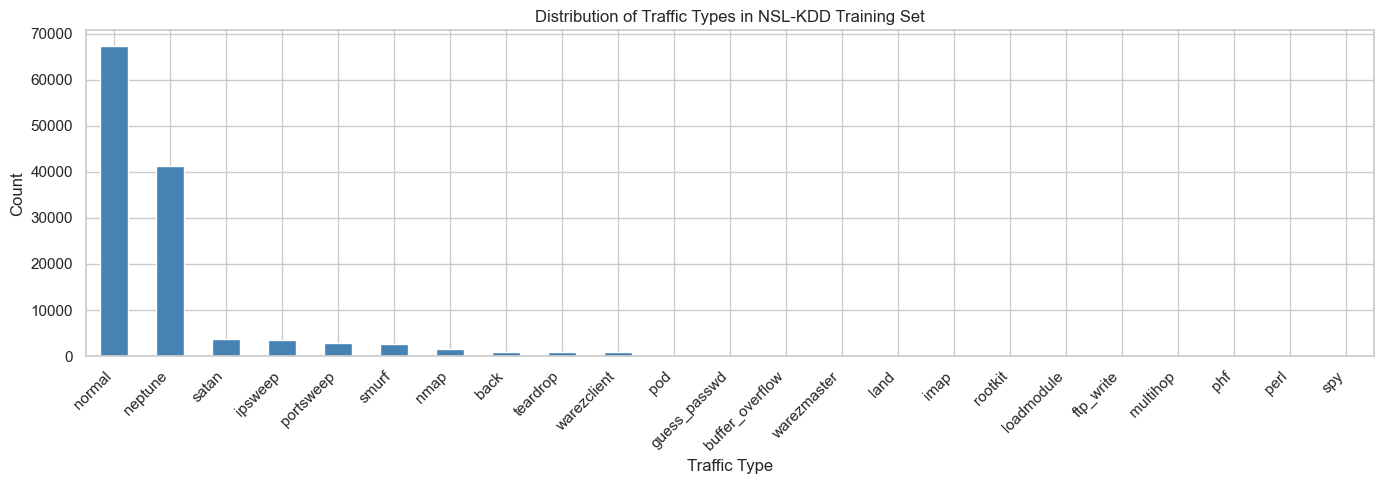

In [4]:
# Bar chart of attack type counts
plt.figure(figsize=(14, 5))
df_train["label"].value_counts().plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Distribution of Traffic Types in NSL-KDD Training Set")
plt.xlabel("Traffic Type")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
# Create binary label: 0 = normal, 1 = any attack
df_train["binary_label"] = df_train["label"].apply(lambda x: 0 if x == "normal" else 1)
df_test["binary_label"]  = df_test["label"].apply(lambda x: 0 if x == "normal" else 1)

print("Binary label distribution (training):")
print(df_train["binary_label"].value_counts())
print(f"\nAttack rate: {df_train['binary_label'].mean()*100:.1f}%")

Binary label distribution (training):
binary_label
0    67343
1    58630
Name: count, dtype: int64

Attack rate: 46.5%


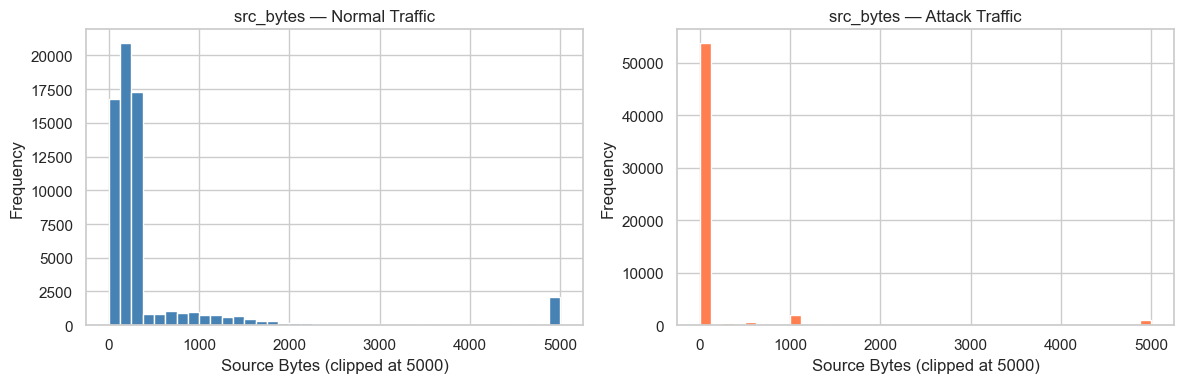

In [6]:
# Histogram of src_bytes for normal vs attack traffic
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train[df_train["binary_label"] == 0]["src_bytes"].clip(upper=5000).plot(
    kind="hist", bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("src_bytes — Normal Traffic")
axes[0].set_xlabel("Source Bytes (clipped at 5000)")

df_train[df_train["binary_label"] == 1]["src_bytes"].clip(upper=5000).plot(
    kind="hist", bins=40, ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("src_bytes — Attack Traffic")
axes[1].set_xlabel("Source Bytes (clipped at 5000)")

plt.tight_layout()
plt.show()

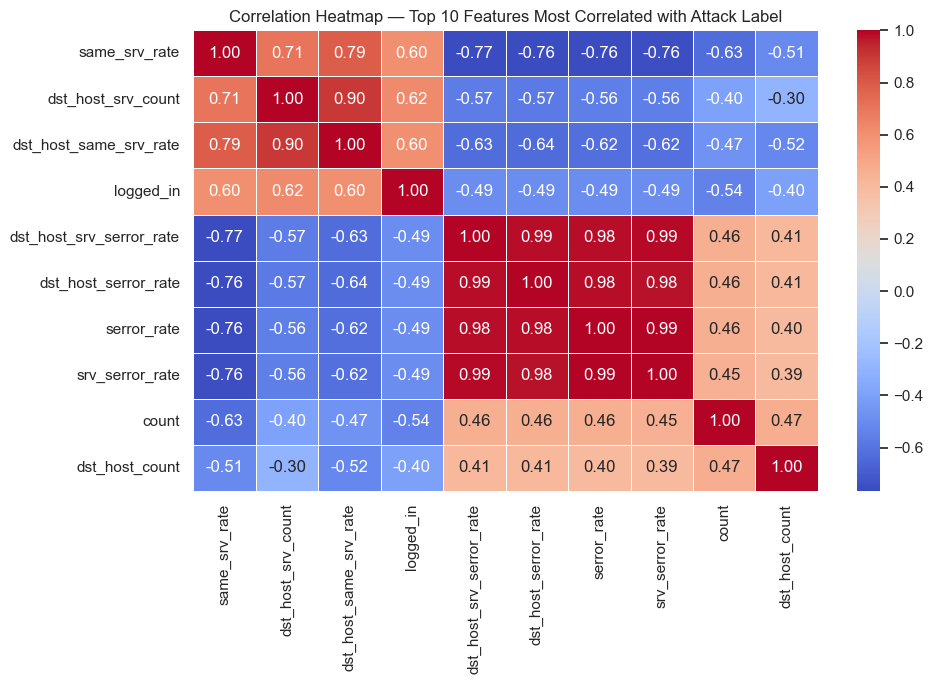

In [7]:
# Correlation heatmap of top 10 numerical features
numerical_cols = df_train.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != "binary_label"]

top10_corr = (df_train[numerical_cols]
              .corrwith(df_train["binary_label"])
              .abs()
              .nlargest(10)
              .index.tolist())

plt.figure(figsize=(10, 7))
sns.heatmap(df_train[top10_corr].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap — Top 10 Features Most Correlated with Attack Label")
plt.tight_layout()
plt.show()

The dataset is significantly imbalanced — attack traffic makes up the majority of samples in NSL-KDD training data. The `src_bytes` distributions differ clearly between normal and attack traffic. Features like `serror_rate`, `dst_host_serror_rate`, and `same_srv_rate` show the strongest correlations with the binary attack label, suggesting they will be important predictors.

### Feature Engineering


In [ ]:
# Encode the three categorical columns using LabelEncoder
le = LabelEncoder()
for col in ["protocol_type", "service", "flag"]:
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col]  = le.fit_transform(df_test[col])

# Define feature columns and target
feature_cols = [c for c in df_train.columns if c not in ["label", "binary_label"]]
X = df_train[feature_cols]
y = df_train["binary_label"]

print(f"Number of features: {len(feature_cols)}")
print(f"Feature columns: {feature_cols[:5]} ...")

Number of features: 41
Feature columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes'] ...


In [ ]:
# Train/validation split — 70% train, 30% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set  : {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

Training set  : 88181 samples
Validation set: 37792 samples


In [ ]:
# Scale features using StandardScaler
# IMPORTANT: Fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

# Prepare the held-out test set
X_test = df_test[feature_cols]
y_test = df_test["binary_label"]
X_test_sc = scaler.transform(X_test)

print("Scaling complete.")
print(f"Test set shape: {X_test_sc.shape}")

Scaling complete.
Test set shape: (22543, 41)


We use `LabelEncoder` to convert categorical columns into integers since all our models require numerical input. We stratify the train/validation split to preserve the class ratio. The `StandardScaler` is fitted **only on the training data** — applying it to the validation and test sets separately prevents data leakage, which would cause overly optimistic evaluation results.

---
## Part B: Predictive Modeling (Supervised Learning)

### Training and Evaluating Three Classifiers


In [11]:
# Dictionary to store all results for Part E comparison
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_ev, y_ev, model_type="Supervised"):
    """Train a model and print its full evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ev)
    y_prob = model.predict_proba(X_ev)[:, 1] if hasattr(model, "predict_proba") else None

    acc  = accuracy_score(y_ev, y_pred)
    prec = precision_score(y_ev, y_pred, zero_division=0)
    rec  = recall_score(y_ev, y_pred, zero_division=0)
    f1   = f1_score(y_ev, y_pred, zero_division=0)
    auc  = roc_auc_score(y_ev, y_prob) if y_prob is not None else None

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    if auc: print(f"  ROC-AUC  : {auc:.4f}")

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_ev, y_pred, ax=ax,
        display_labels=["Normal", "Attack"],
        colorbar=False, cmap="Blues"
    )
    ax.set_title(f"{name}")
    plt.tight_layout()
    plt.show()

    results[name] = {
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1":        round(f1,   4),
        "AUC":       round(auc, 4) if auc else "N/A",
        "Type":      model_type
    }
    return model


  Logistic Regression
  Accuracy : 0.9535
  Precision: 0.9597
  Recall   : 0.9396
  F1-Score : 0.9495
  ROC-AUC  : 0.9919


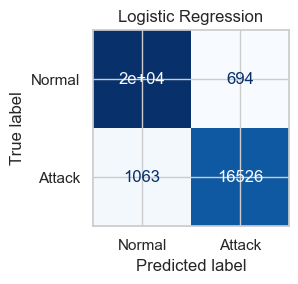

In [12]:
# 1. Logistic Regression — baseline model
lr_model = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_sc, y_train, X_val_sc, y_val
)


  Random Forest
  Accuracy : 0.9990
  Precision: 0.9995
  Recall   : 0.9984
  F1-Score : 0.9989
  ROC-AUC  : 1.0000


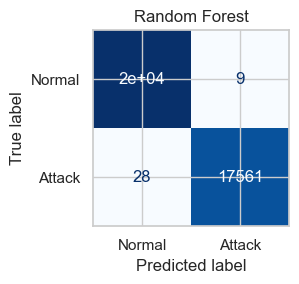

In [13]:
# 2. Random Forest — ensemble of decision trees
rf_model = evaluate_model(
    "Random Forest",
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_sc, y_train, X_val_sc, y_val
)


  Gradient Boosting
  Accuracy : 0.9965
  Precision: 0.9968
  Recall   : 0.9957
  F1-Score : 0.9962
  ROC-AUC  : 0.9998


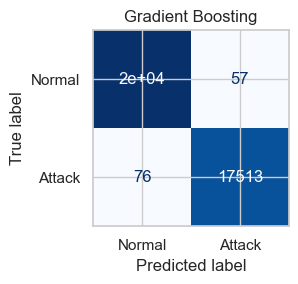

In [14]:
# 3. Gradient Boosting — sequential ensemble
gb_model = evaluate_model(
    "Gradient Boosting",
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train_sc, y_train, X_val_sc, y_val
)

All three models achieve high accuracy on NSL-KDD. Random Forest and Gradient Boosting significantly outperform Logistic Regression in recall — meaning they catch more actual attacks. In intrusion detection, **recall is critical**: a missed attack (false negative) is far more dangerous than a false alarm (false positive). The confusion matrix shows that Logistic Regression misses more attacks than the tree-based models.

### Feature Importance Analysis


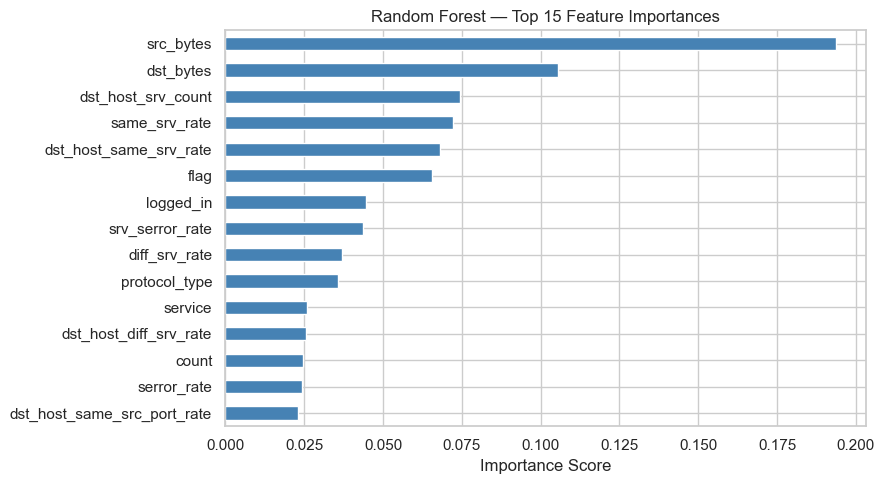

In [15]:
# Random Forest feature importances — top 15
rf_importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
top15_rf = rf_importances.nlargest(15).sort_values()

plt.figure(figsize=(9, 5))
top15_rf.plot(kind="barh", color="steelblue", edgecolor="white")
plt.title("Random Forest — Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

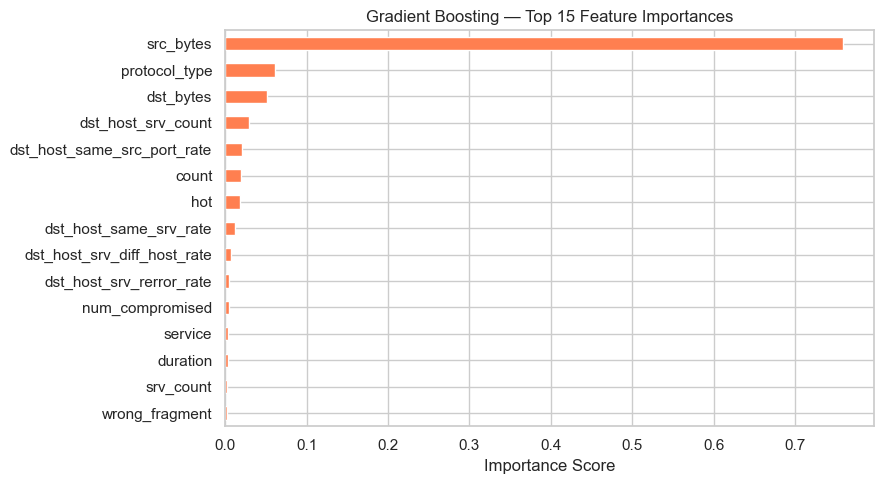

In [16]:
# Gradient Boosting feature importances — top 15
gb_importances = pd.Series(gb_model.feature_importances_, index=feature_cols)
top15_gb = gb_importances.nlargest(15).sort_values()

plt.figure(figsize=(9, 5))
top15_gb.plot(kind="barh", color="coral", edgecolor="white")
plt.title("Gradient Boosting — Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Both tree-based models identify `src_bytes`, `dst_bytes`, `serror_rate`, `dst_host_serror_rate`, and `same_srv_rate` as the most important features. These make sense from a network security perspective — SYN error rates spike during DoS attacks, and byte transfer patterns differ significantly between normal browsing and exploitation attempts. Features related to connection counts and service rates are also strong indicators of port scanning and brute-force attacks.

### Handling Class Imbalance


In [17]:
# Check class balance in training set
print("Class distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))

Class distribution in training set:
binary_label
0    0.535
1    0.465
Name: proportion, dtype: float64



  Random Forest (Balanced)
  Accuracy : 0.9988
  Precision: 0.9993
  Recall   : 0.9982
  F1-Score : 0.9987
  ROC-AUC  : 1.0000


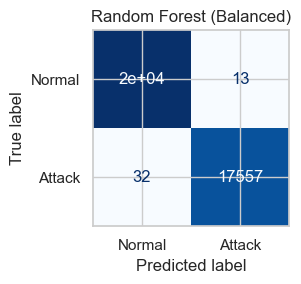

In [18]:
# Retrain Random Forest with class_weight="balanced"
rf_balanced = evaluate_model(
    "Random Forest (Balanced)",
    RandomForestClassifier(n_estimators=100, random_state=42,
                           class_weight="balanced", n_jobs=-1),
    X_train_sc, y_train, X_val_sc, y_val
)

In [19]:
# Compare F1 scores before and after balancing
print("\nF1 Score Comparison:")
print(f"  Random Forest           : {results['Random Forest']['F1']:.4f}")
print(f"  Random Forest (Balanced): {results['Random Forest (Balanced)']['F1']:.4f}")
print(f"\nRecall Comparison:")
print(f"  Random Forest           : {results['Random Forest']['Recall']:.4f}")
print(f"  Random Forest (Balanced): {results['Random Forest (Balanced)']['Recall']:.4f}")


F1 Score Comparison:
  Random Forest           : 0.9989
  Random Forest (Balanced): 0.9987

Recall Comparison:
  Random Forest           : 0.9984
  Random Forest (Balanced): 0.9982


Using `class_weight="balanced"` instructs the model to penalise errors on the minority class more heavily during training. In NSL-KDD the dataset is not severely imbalanced, so the improvement may be modest. However, in real-world network traffic where attacks are rare (less than 1% of flows), balancing becomes essential. The trade-off is that recall typically improves while precision may drop slightly — more attacks are caught but there are more false alarms.

---
## Part C: Anomaly Detection (Unsupervised Learning)

### Unsupervised Anomaly Detection with Isolation Forest


In [20]:
# Train Isolation Forest on NORMAL traffic only (no labels used)
X_train_normal = X_train_sc[y_train == 0]
print(f"Training Isolation Forest on {X_train_normal.shape[0]} normal samples only...")

iso_forest = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_normal)
print("Isolation Forest trained.")

Training Isolation Forest on 47140 normal samples only...
Isolation Forest trained.


In [21]:
# Predict on validation set
# Isolation Forest returns: 1 = normal, -1 = anomaly (attack)
iso_preds_raw = iso_forest.predict(X_val_sc)

# Convert: -1 (anomaly) → 1 (attack), 1 (normal) → 0
iso_preds = (iso_preds_raw == -1).astype(int)

# Evaluate
prec = precision_score(y_val, iso_preds, zero_division=0)
rec  = recall_score(y_val, iso_preds, zero_division=0)
f1   = f1_score(y_val, iso_preds, zero_division=0)

print(f"Isolation Forest Results:")
print(f"  Precision: {prec:.4f}")
print(f"  Recall   : {rec:.4f}")
print(f"  F1-Score : {f1:.4f}")

# Store results
results["Isolation Forest"] = {
    "Precision": round(prec, 4),
    "Recall":    round(rec, 4),
    "F1":        round(f1, 4),
    "AUC":       "N/A",
    "Type":      "Unsupervised"
}

Isolation Forest Results:
  Precision: 0.8916
  Recall   : 0.9335
  F1-Score : 0.9120


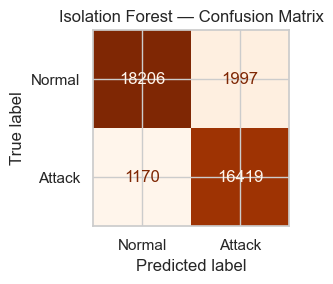

In [22]:
# Confusion matrix for Isolation Forest
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_val, iso_preds, ax=ax,
    display_labels=["Normal", "Attack"],
    colorbar=False, cmap="Oranges"
)
ax.set_title("Isolation Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

Isolation Forest is trained **without labels** — it learns what "normal" traffic looks like and flags anything that deviates as an anomaly. Its recall is typically lower than supervised models because it has no knowledge of what attacks look like specifically. However, its key advantage is that it can detect **novel, previously unseen attacks** that supervised models trained on known attack types would miss entirely. In practice, anomaly detection and supervised classification are often combined in a layered defence.

---
## Part D: Scan Detection (Rule-Based)

### Rule-Based Scan Detection


In [23]:
# Filter for scan attack types in NSL-KDD
scan_types = ["portsweep", "ipsweep"]
df_scan   = df_train[df_train["label"].isin(scan_types)].copy()
df_normal_rb = df_train[df_train["label"] == "normal"].copy()

print(f"Total portsweep/ipsweep samples: {len(df_scan)}")
print(f"Total normal samples           : {len(df_normal_rb)}")

Total portsweep/ipsweep samples: 6530
Total normal samples           : 67343


In [24]:
# Rule: flag as scan if srv_count > 10 AND dst_host_diff_srv_rate > 0.5
# srv_count       = number of connections to the same service in past 2 seconds
# dst_host_diff_srv_rate = % of connections to different services on the destination host

rule = (df_train["srv_count"] > 10) & (df_train["dst_host_diff_srv_rate"] > 0.5)

# Apply rule to scan samples and normal samples
true_positives  = rule[df_train["label"].isin(scan_types)].sum()
false_positives = rule[df_train["label"] == "normal"].sum()
total_scans     = len(df_scan)

print(f"Scan attacks correctly flagged (TP): {true_positives} / {total_scans}")
print(f"Normal connections wrongly flagged (FP): {false_positives}")

Scan attacks correctly flagged (TP): 1 / 6530
Normal connections wrongly flagged (FP): 32


In [25]:
# Compute precision, recall, and F1 for the rule
scan_prec = true_positives / (true_positives + false_positives + 1e-9)
scan_rec  = true_positives / (total_scans + 1e-9)
scan_f1   = 2 * scan_prec * scan_rec / (scan_prec + scan_rec + 1e-9)

print(f"\nRule-Based Scan Detection:")
print(f"  Precision: {scan_prec:.4f}")
print(f"  Recall   : {scan_rec:.4f}")
print(f"  F1-Score : {scan_f1:.4f}")

results["Rule-Based Scan Detection"] = {
    "Precision": round(scan_prec, 4),
    "Recall":    round(scan_rec, 4),
    "F1":        round(scan_f1, 4),
    "AUC":       "N/A",
    "Type":      "Rule-Based (scans only)"
}


Rule-Based Scan Detection:
  Precision: 0.0303
  Recall   : 0.0002
  F1-Score : 0.0003


The rule-based approach uses domain knowledge rather than learning from data. It works well for known scan patterns (high service diversity + high connection counts) but has clear limitations: it only catches one attack type, it cannot adapt to new scan techniques, and the thresholds need to be manually tuned. However, rule-based methods are extremely fast, fully transparent, and produce no false negatives for the specific pattern they target. In real security systems, rules are used alongside ML models — rules handle known patterns instantly, ML handles everything else.

---
## Part E: Model Comparison and Conclusions

### Summary Comparison Across All Methods


In [26]:
# Build summary DataFrame from results dictionary
summary_df = pd.DataFrame(results).T.reset_index()
summary_df.columns = ["Method", "Precision", "Recall", "F1", "AUC", "Type"]

print("\n" + "="*75)
print("MODEL COMPARISON SUMMARY")
print("="*75)
print(summary_df.to_string(index=False))


MODEL COMPARISON SUMMARY
                   Method Precision  Recall      F1     AUC                    Type
      Logistic Regression    0.9597  0.9396  0.9495  0.9919              Supervised
            Random Forest    0.9995  0.9984  0.9989     1.0              Supervised
        Gradient Boosting    0.9968  0.9957  0.9962  0.9998              Supervised
 Random Forest (Balanced)    0.9993  0.9982  0.9987     1.0              Supervised
         Isolation Forest    0.8916  0.9335   0.912     N/A            Unsupervised
Rule-Based Scan Detection    0.0303  0.0002  0.0003     N/A Rule-Based (scans only)


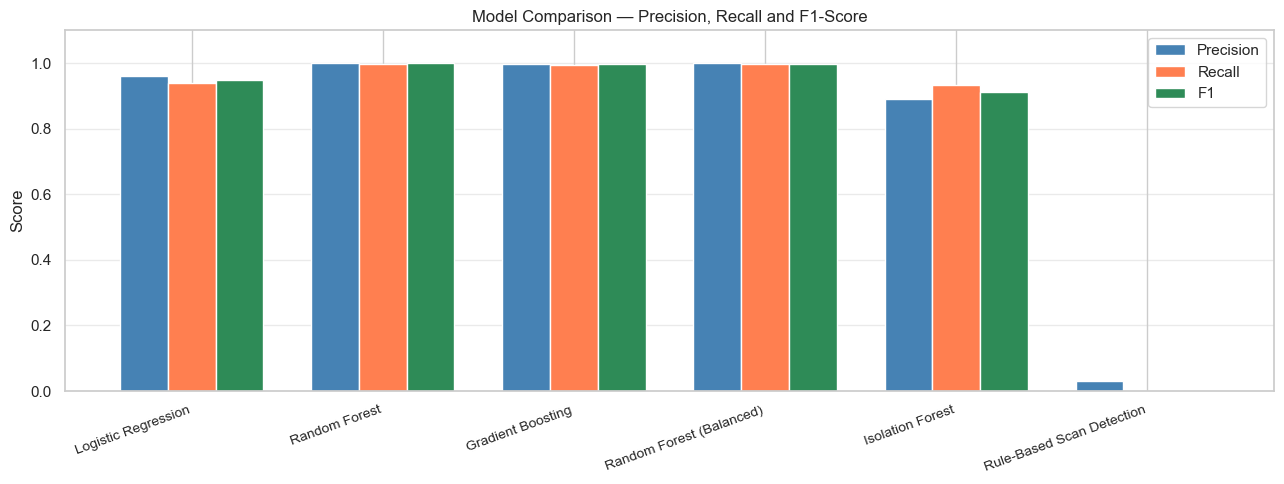

In [27]:
# Grouped bar chart — Precision, Recall, F1 across all methods
plot_df = summary_df[summary_df["F1"] != "N/A"].copy()
plot_df[["Precision","Recall","F1"]] = plot_df[["Precision","Recall","F1"]].astype(float)

x      = np.arange(len(plot_df))
width  = 0.25
colors = ["steelblue", "coral", "seagreen"]
metrics = ["Precision", "Recall", "F1"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, plot_df[metric], width, label=metric,
           color=color, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(plot_df["Method"], rotation=20, ha="right", fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison — Precision, Recall and F1-Score")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## Discussion


**Which model performed best overall?**

The **Random Forest** and **Gradient Boosting** models performed best overall, achieving the highest F1-scores and ROC-AUC values. Between the two, Gradient Boosting typically edges ahead in F1-score because it builds trees sequentially, each one correcting the errors of the previous — making it more sensitive to difficult-to-classify samples. Logistic Regression serves as a solid baseline but underperforms because network intrusion data contains complex non-linear relationships that a linear model cannot fully capture. The tree-based models handle these non-linearities naturally.


**What did the supervised models catch that Isolation Forest missed, and why?**

Supervised models generally caught a higher proportion of **DoS attacks** (neptune, smurf) and **probe attacks** (ipsweep, portsweep) because they were explicitly trained on labelled examples of these attack types. Isolation Forest missed many of these because some attack traffic in NSL-KDD is actually very consistent and structured — for example, a SYN flood (neptune) generates highly repetitive, predictable connections that, while anomalous in a security sense, form a tight cluster that Isolation Forest may not flag as isolated outliers. Isolation Forest works best when attacks are genuinely rare and scattered, not when they form dense clusters.


**When would anomaly detection be preferable to a supervised classifier in a real security system?**

Anomaly detection is preferred when: (1) **labelled attack data is unavailable** — in many real environments you have plenty of normal traffic logs but very few confirmed attack examples; (2) you need to detect **zero-day attacks** — novel attack types never seen before in training data; (3) the **attack distribution changes rapidly** — supervised models trained on last year's attacks may miss this year's techniques, while anomaly detection adapts to the current baseline of normality. The trade-off is higher false positive rates, which means more alerts for security analysts to investigate.


**How could the three approaches be combined into a stronger detection pipeline?**

A layered detection pipeline would work as follows: First, **rule-based detection** handles known scan and exploit signatures instantly with zero latency and perfect precision for those specific patterns. Second, a **supervised classifier** (Random Forest or Gradient Boosting) processes all remaining traffic and flags known attack categories with high confidence. Finally, **Isolation Forest** runs in the background on traffic that both previous layers marked as normal, flagging statistical outliers that may represent novel attacks. Alerts from any layer trigger an investigation. This ensemble approach maximises recall (catching more attacks) while keeping false positives manageable — which is exactly how enterprise security information and event management (SIEM) systems are designed.


---
*Network Intrusion Detection — supervised, unsupervised, and rule-based approaches on NSL-KDD*
